<a href="https://colab.research.google.com/github/0xjessie21/data-science-2026/blob/main/Pertemuan4_MOHAMMAD_RIYAN_SYAIFUNAHAR_240401010292.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 4 — Statistika Dasar & Analisis Data
**Nama:** MOHAMMAD RIYAN SYAIFUNAHAR  
**NIM:** 240401010292  
**Mata Kuliah:** Pengantar Data Science  
**Dataset:** Iris (150 baris, 5 kolom — sepal_length, sepal_width, petal_length, petal_width, species)

---
## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Langkah 1 — Load & Inspect Dataset

In [2]:
df = sns.load_dataset('iris')

print('Shape:', df.shape)
print('\nTipe data per kolom:')
print(df.dtypes)

Shape: (150, 5)

Tipe data per kolom:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [3]:
print('5 Baris Pertama:')
df.head()

5 Baris Pertama:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print('Statistik Deskriptif Awal:')
df.describe().round(3)

Statistik Deskriptif Awal:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [5]:
print('Jumlah data per spesies:')
print(df['species'].value_counts())

Jumlah data per spesies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


**Temuan Langkah 1:**  
- Dataset Iris memiliki **150 baris** dan **5 kolom**  
- 4 kolom bertipe `float64` (numerik) dan 1 kolom bertipe `object` (kategorik: species)  
- Terdapat **3 spesies** masing-masing **50 data**: setosa, versicolor, virginica  
- Tidak ada missing values pada dataset ini (count = 150 untuk semua kolom numerik)

---
## Langkah 2 — Statistik Deskriptif Lengkap

In [6]:
print('=' * 50)
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean        : {col.mean():.3f}')
    print(f'  Median      : {col.median():.3f}')
    print(f'  Modus       : {col.mode().values}')
    print(f'  Std Dev     : {col.std():.3f}')
    print(f'  Varians     : {col.var():.3f}')
    print(f'  Skewness    : {col.skew():.3f}')
    print(f'  Kurtosis    : {col.kurt():.3f}')
    print(f'  Q1          : {col.quantile(0.25):.3f}')
    print(f'  Q2 (Median) : {col.quantile(0.50):.3f}')
    print(f'  Q3          : {col.quantile(0.75):.3f}')
    print(f'  IQR         : {col.quantile(0.75) - col.quantile(0.25):.3f}')


=== sepal_length ===
  Mean        : 5.843
  Median      : 5.800
  Modus       : [5.]
  Std Dev     : 0.828
  Varians     : 0.686
  Skewness    : 0.315
  Kurtosis    : -0.552
  Q1          : 5.100
  Q2 (Median) : 5.800
  Q3          : 6.400
  IQR         : 1.300

=== sepal_width ===
  Mean        : 3.057
  Median      : 3.000
  Modus       : [3.]
  Std Dev     : 0.436
  Varians     : 0.190
  Skewness    : 0.319
  Kurtosis    : 0.228
  Q1          : 2.800
  Q2 (Median) : 3.000
  Q3          : 3.300
  IQR         : 0.500

=== petal_length ===
  Mean        : 3.758
  Median      : 4.350
  Modus       : [1.4 1.5]
  Std Dev     : 1.765
  Varians     : 3.116
  Skewness    : -0.275
  Kurtosis    : -1.402
  Q1          : 1.600
  Q2 (Median) : 4.350
  Q3          : 5.100
  IQR         : 3.500

=== petal_width ===
  Mean        : 1.199
  Median      : 1.300
  Modus       : [0.2]
  Std Dev     : 0.762
  Varians     : 0.581
  Skewness    : -0.103
  Kurtosis    : -1.341
  Q1          : 0.300
  Q2 

In [7]:
numerik_cols = df.select_dtypes(include='number').columns
ringkasan = pd.DataFrame({
    'Mean'    : df[numerik_cols].mean().round(3),
    'Median'  : df[numerik_cols].median().round(3),
    'Std'     : df[numerik_cols].std().round(3),
    'Skewness': df[numerik_cols].skew().round(3),
    'Kurtosis': df[numerik_cols].kurt().round(3)
})

print('=== Tabel Ringkasan Statistik ===')
ringkasan

=== Tabel Ringkasan Statistik ===


,Mean,Median,Std,Skewness,Kurtosis
sepal_length,5.843,5.80,0.828,0.315,-0.552
sepal_width,3.057,3.00,0.436,0.319,0.228
petal_length,3.758,4.35,1.765,-0.275,-1.402
petal_width,1.199,1.30,0.762,-0.103,-1.341


In [8]:
print('=== Uji Skewness (SciPy) ===')
for col_name in numerik_cols:
    col = df[col_name].dropna()
    skew_stat, p = stats.skewtest(col)
    interpretasi = 'Simetris' if abs(df[col_name].skew()) < 0.5 else ('Right-Skewed' if df[col_name].skew() > 0 else 'Left-Skewed')
    print(f'{col_name:15s}: skew={df[col_name].skew():.3f} | stat={skew_stat:.3f} | p={p:.4f} | {interpretasi}')

=== Uji Skewness (SciPy) ===
sepal_length   : skew=0.315 | stat=1.596 | p=0.1104 | Simetris
sepal_width    : skew=0.319 | stat=1.616 | p=0.1061 | Simetris
petal_length   : skew=-0.275 | stat=-1.400 | p=0.1615 | Simetris
petal_width    : skew=-0.103 | stat=-0.531 | p=0.5952 | Simetris


**Temuan Langkah 2:**  
- `sepal_length`: Skewness ≈ 0.31 → **Simetris/mendekati normal**  
- `sepal_width`: Skewness ≈ 0.32 → **Simetris/mendekati normal**  
- `petal_length`: Skewness ≈ -0.27 → **Simetris** (tapi distribusinya bimodal karena 3 spesies)  
- `petal_width`: Skewness ≈ -0.10 → **Simetris** (juga bimodal)  
- Perbedaan Mean vs Median kecil di semua kolom → tidak ada distorsi outlier yang signifikan

---
## Langkah 3 — Analisis Distribusi (Histogram + KDE)

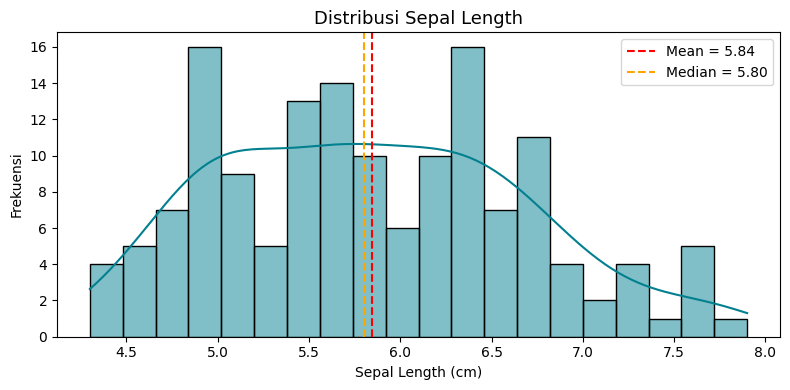

Skewness sepal_length: 0.315


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(df['sepal_length'], kde=True,
             color='#028090', bins=20, ax=ax)

ax.axvline(df['sepal_length'].mean(),
           color='red', linestyle='--', linewidth=1.5,
           label=f"Mean = {df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(),
           color='orange', linestyle='--', linewidth=1.5,
           label=f"Median = {df['sepal_length'].median():.2f}")

ax.set_title('Distribusi Sepal Length', fontsize=13)
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Skewness sepal_length: {df['sepal_length'].skew():.3f}")

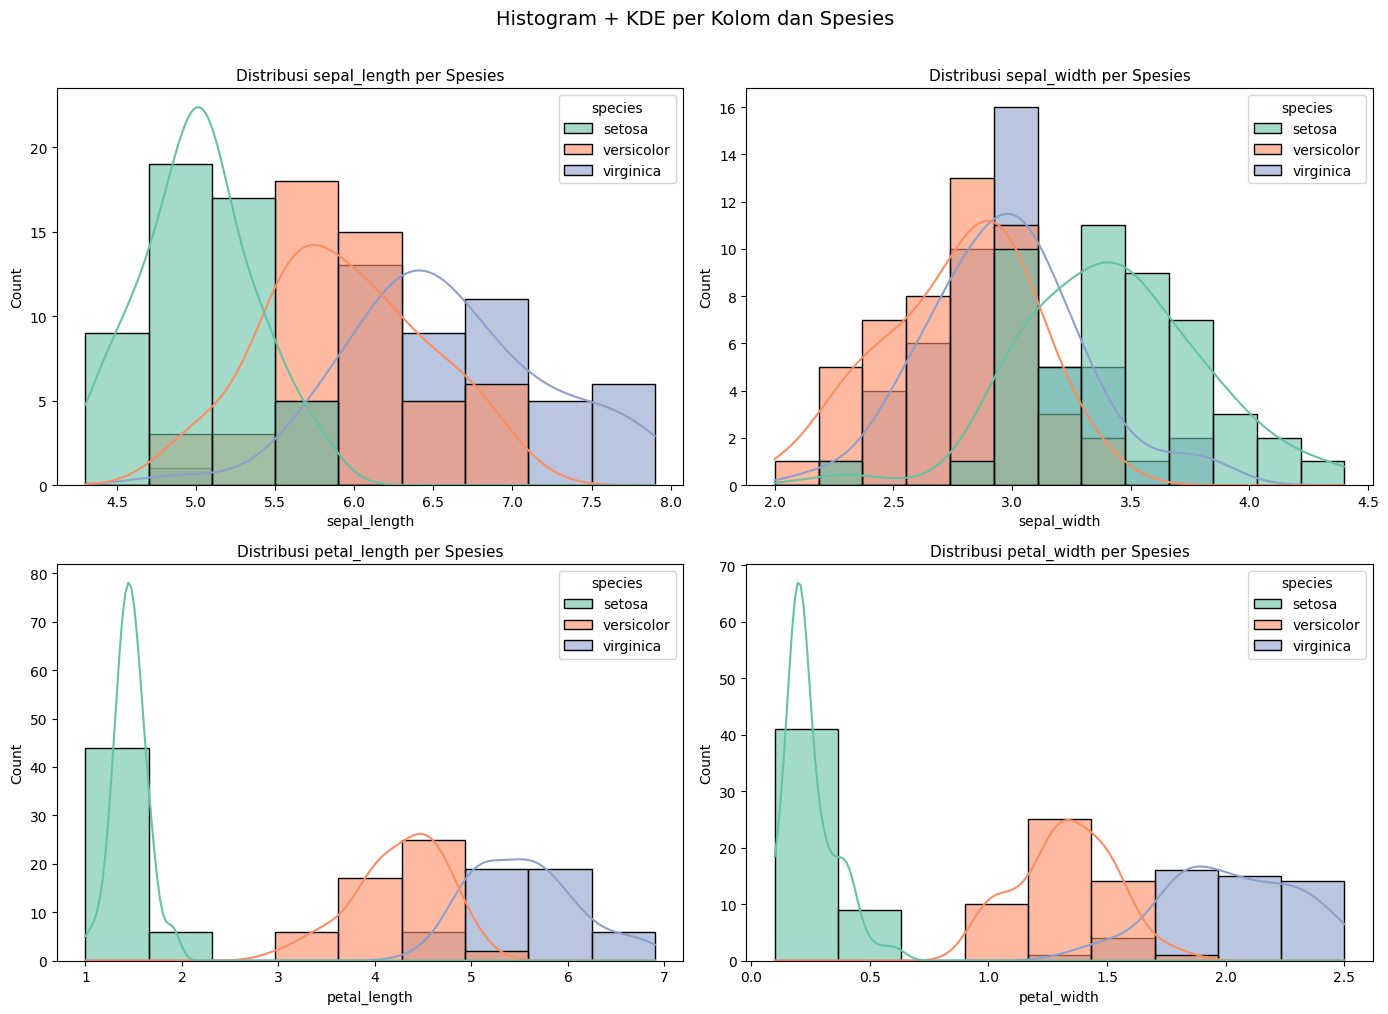

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col_name in enumerate(numerik_cols):
    sns.histplot(data=df, x=col_name, hue='species',
                 kde=True, palette='Set2', alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Distribusi {col_name} per Spesies', fontsize=11)
    axes[i].set_xlabel(col_name)

plt.suptitle('Histogram + KDE per Kolom dan Spesies', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Temuan Langkah 3:**  
- `sepal_length`: Distribusi mendekati **normal** dengan sedikit miring kanan (skewness=0.31). Mean ≈ Median  
- `petal_length` & `petal_width`: Terlihat **bimodal** saat dilihat keseluruhan — karena spesies *setosa* jauh lebih kecil dibanding *versicolor* dan *virginica*  
- Saat dipisah per spesies, tiap kolom mendekati distribusi **normal** untuk masing-masing spesies

---
## Langkah 4 — Boxplot per Spesies

/tmp/ipykernel_2683/3552620051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length',
/tmp/ipykernel_2683/3552620051.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length',


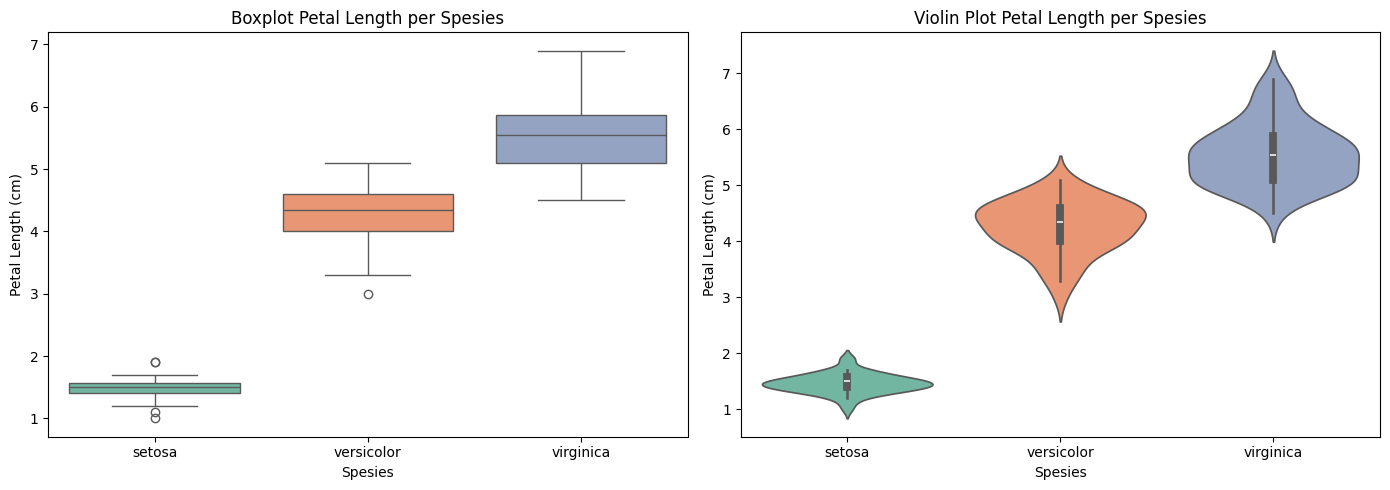

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='species', y='petal_length',
            palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length per Spesies', fontsize=12)
axes[0].set_xlabel('Spesies')
axes[0].set_ylabel('Petal Length (cm)')

sns.violinplot(data=df, x='species', y='petal_length',
               palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length per Spesies', fontsize=12)
axes[1].set_xlabel('Spesies')
axes[1].set_ylabel('Petal Length (cm)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2683/3075317643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col_name,
/tmp/ipykernel_2683/3075317643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col_name,
/tmp/ipykernel_2683/3075317643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col_name,
/tmp/ipykernel_2683/3075317643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False

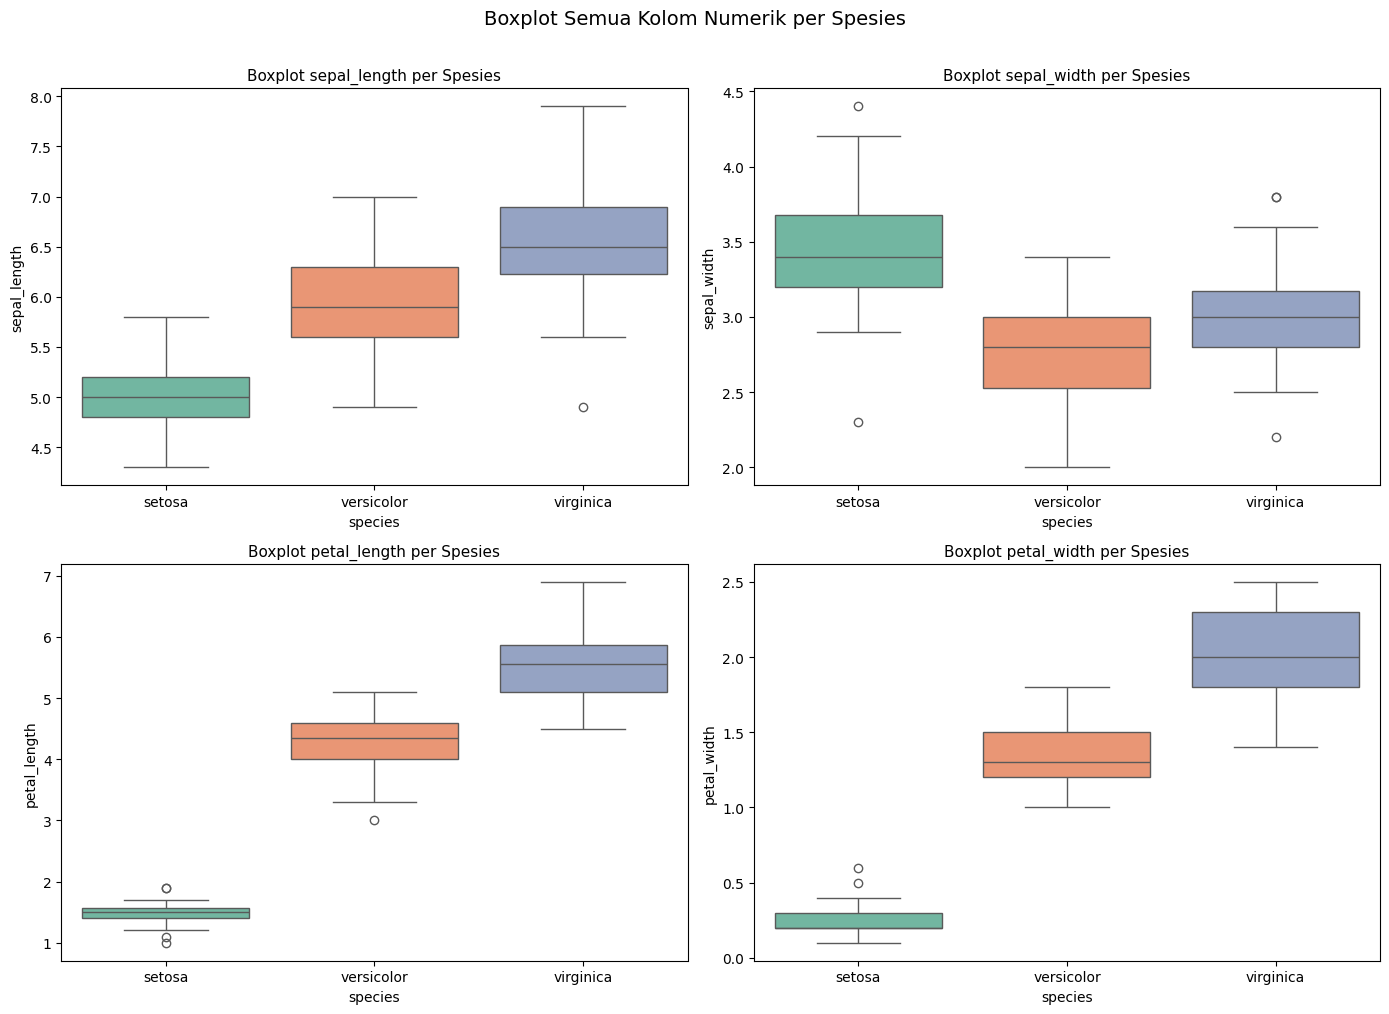

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col_name in enumerate(numerik_cols):
    sns.boxplot(data=df, x='species', y=col_name,
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'Boxplot {col_name} per Spesies', fontsize=11)

plt.suptitle('Boxplot Semua Kolom Numerik per Spesies', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
print('=== Statistik petal_length per Spesies ===')
print(df.groupby('species')['petal_length'].agg(['min','max','mean','std']).round(3))

print('\n=== Spesies dengan petal_length terbesar ===')
print(df.groupby('species')['petal_length'].mean().idxmax())

print('\n=== Spesies dengan petal_length terkecil ===')
print(df.groupby('species')['petal_length'].mean().idxmin())

print('\n=== Spesies dengan sebaran terluas (std tertinggi) ===')
print(df.groupby('species')['petal_length'].std().idxmax())

=== Statistik petal_length per Spesies ===
            min  max   mean    std
species                           
setosa      1.0  1.9  1.462  0.174
versicolor  3.0  5.1  4.260  0.470
virginica   4.5  6.9  5.552  0.552

=== Spesies dengan petal_length terbesar ===
virginica

=== Spesies dengan petal_length terkecil ===
setosa

=== Spesies dengan sebaran terluas (std tertinggi) ===
virginica


**Temuan Langkah 4:**  
- **Virginica** memiliki `petal_length` **terbesar** (rata-rata ≈ 5.55 cm)  
- **Setosa** memiliki `petal_length` **terkecil** (rata-rata ≈ 1.46 cm) — jauh berbeda dari dua spesies lain  
- **Virginica** memiliki sebaran **paling luas** (std tertinggi)  
- Violin plot memperlihatkan distribusi *setosa* yang sempit dan terpusat, sedangkan *virginica* lebih tersebar  
- Tidak terlihat outlier ekstrem pada boxplot petal_length

---
## Langkah 5 — Matriks Korelasi Pearson

In [14]:
corr = df.drop('species', axis=1).corr(method='pearson')
print('=== Matriks Korelasi Pearson ===')
print(corr.round(3))

=== Matriks Korelasi Pearson ===
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


In [15]:
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print(f'Korelasi TERTINGGI : {max_pair} = {corr.loc[max_pair]:.3f}')
print(f'Korelasi TERENDAH  : {min_pair} = {corr.loc[min_pair]:.3f}')

Korelasi TERTINGGI : ('petal_width', 'petal_length') = 0.963
Korelasi TERENDAH  : ('petal_length', 'sepal_width') = -0.428


In [16]:
print('=== Perbandingan Pearson vs Spearman ===')
cols = list(numerik_cols)
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        x = df[cols[i]]
        y = df[cols[j]]
        r,  p_r = stats.pearsonr(x, y)
        rho, p_s = stats.spearmanr(x, y)
        print(f'{cols[i]:15s} vs {cols[j]:15s} | Pearson r={r:.3f} (p={p_r:.4f}) | Spearman ρ={rho:.3f} (p={p_s:.4f})')

=== Perbandingan Pearson vs Spearman ===
sepal_length    vs sepal_width     | Pearson r=-0.118 (p=0.1519) | Spearman ρ=-0.167 (p=0.0414)
sepal_length    vs petal_length    | Pearson r=0.872 (p=0.0000) | Spearman ρ=0.882 (p=0.0000)
sepal_length    vs petal_width     | Pearson r=0.818 (p=0.0000) | Spearman ρ=0.834 (p=0.0000)
sepal_width     vs petal_length    | Pearson r=-0.428 (p=0.0000) | Spearman ρ=-0.310 (p=0.0001)
sepal_width     vs petal_width     | Pearson r=-0.366 (p=0.0000) | Spearman ρ=-0.289 (p=0.0003)
petal_length    vs petal_width     | Pearson r=0.963 (p=0.0000) | Spearman ρ=0.938 (p=0.0000)


**Temuan Langkah 5:**  
- Korelasi **tertinggi**: `petal_length` vs `petal_width` ≈ **0.963** → sangat kuat positif  
- Korelasi **terendah**: `sepal_width` vs `petal_length` ≈ **-0.428** → lemah negatif  
- `sepal_width` berkorelasi **negatif** dengan semua kolom petal — semakin lebar sepal, semakin kecil petal  
- `petal_length` dan `petal_width` sangat berkorelasi → keduanya mengukur dimensi mahkota yang saling berkaitan  
- Nilai Pearson dan Spearman sangat mirip → hubungan bersifat **linear**

---
## Langkah 6 — Scatter Plot & Heatmap

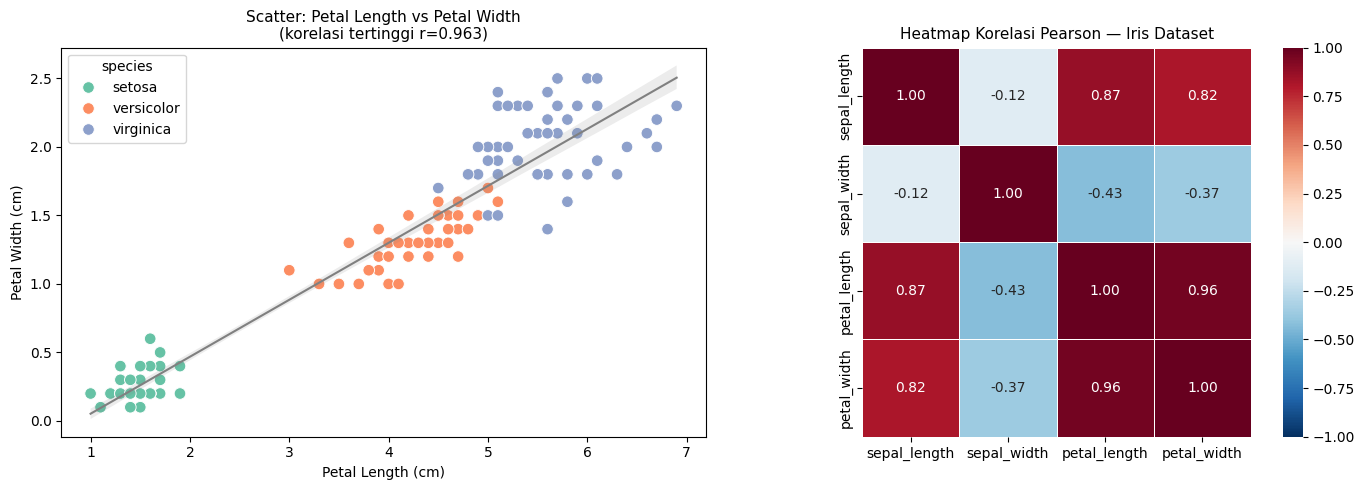

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set2', s=70, ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
            scatter=False, color='gray', line_kws={'linewidth':1.5}, ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width\n(korelasi tertinggi r=0.963)', fontsize=11)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='white', ax=axes[1])
axes[1].set_title('Heatmap Korelasi Pearson — Iris Dataset', fontsize=11)

plt.tight_layout()
plt.show()

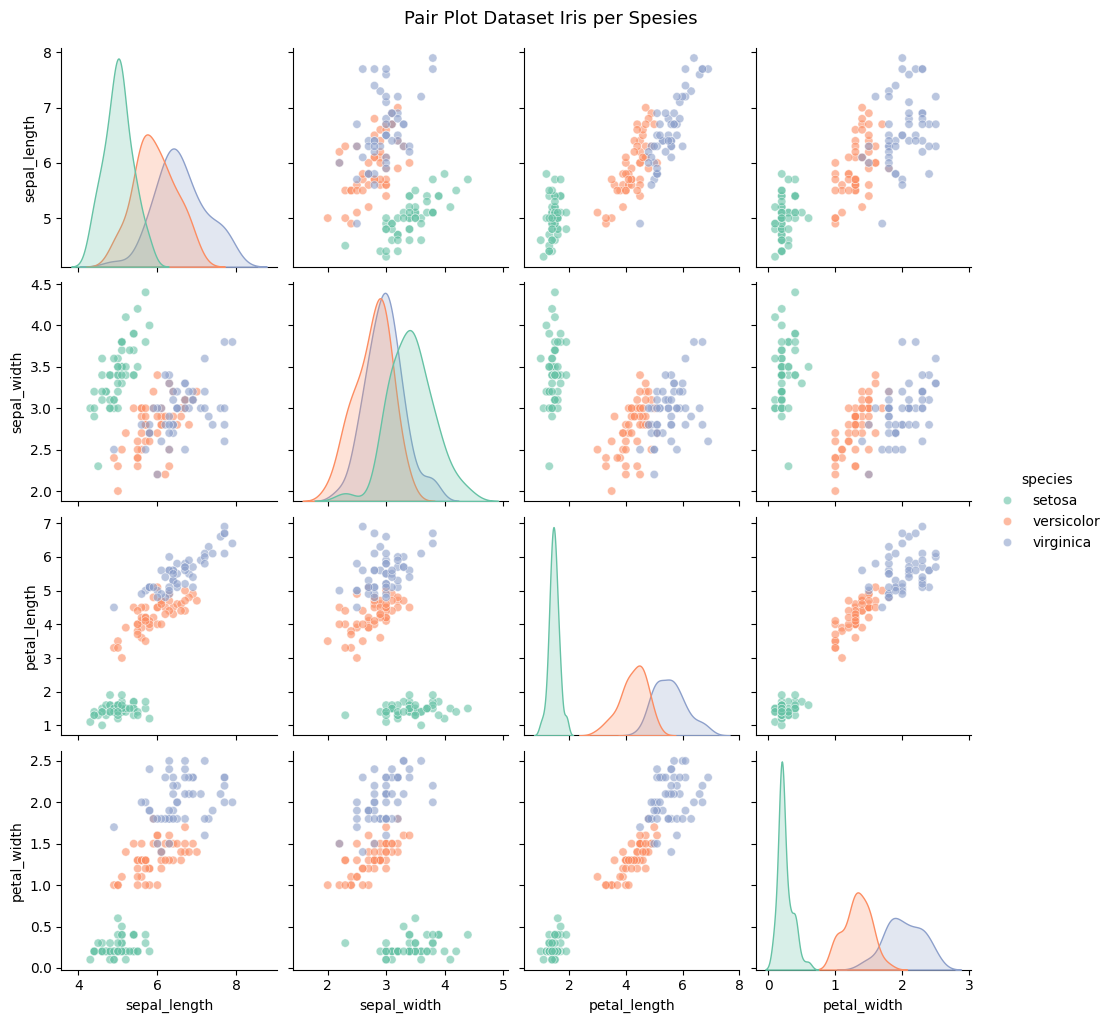

In [18]:
g = sns.pairplot(df, hue='species', palette='Set2',
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pair Plot Dataset Iris per Spesies', y=1.02, fontsize=13)
plt.show()

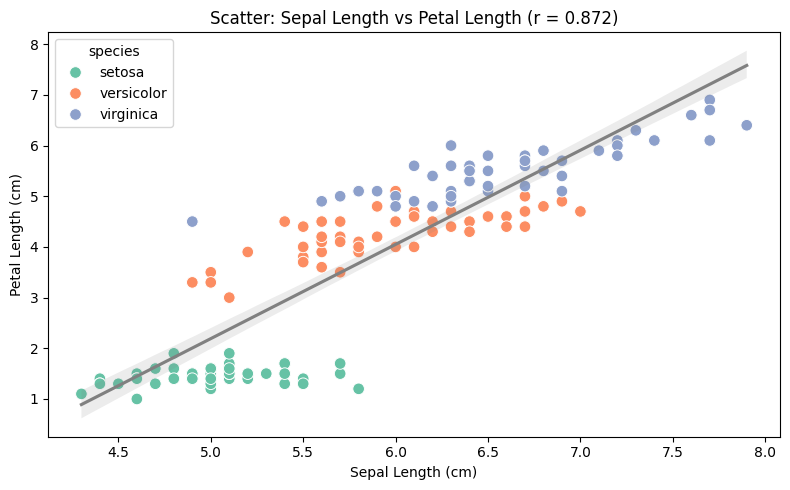

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='sepal_length', y='petal_length',
                hue='species', palette='Set2', s=70, ax=ax)
sns.regplot(data=df, x='sepal_length', y='petal_length',
            scatter=False, color='gray', ax=ax)

r_val, _ = stats.pearsonr(df['sepal_length'], df['petal_length'])
ax.set_title(f'Scatter: Sepal Length vs Petal Length (r = {r_val:.3f})', fontsize=12)
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
plt.tight_layout()
plt.show()

**Temuan Langkah 6:**  
- Scatter plot `petal_length` vs `petal_width` menunjukkan **tren naik sangat jelas** → korelasi positif sangat kuat (r=0.963)  
- Ketiga spesies terlihat **terpisah secara visual** pada scatter plot — setosa paling mudah dibedakan  
- Heatmap memperlihatkan kolom `sepal_width` berwarna **biru** (korelasi negatif) terhadap kolom petal  
- Pair plot membuktikan bahwa `petal_length` dan `petal_width` adalah **pasangan terbaik** untuk membedakan spesies  
- **Kesimpulan:** Dimensi mahkota (petal) jauh lebih informatif dibanding dimensi kelopak (sepal) untuk klasifikasi spesies Iris

---
## Ringkasan Hasil Analisis Dataset Iris

| Langkah | Topik | Temuan Utama |
|---------|-------|--------------|
| 1 | Load & Inspect | 150 baris, 5 kolom, 3 spesies (50 data masing-masing) |
| 2 | Statistik Deskriptif | Semua kolom mendekati simetris; petal lebih bervariasi dari sepal |
| 3 | Histogram + KDE | sepal_length normal; petal_length bimodal (karena 3 spesies) |
| 4 | Boxplot per Spesies | Virginica terbesar, Setosa terkecil dan paling seragam |
| 5 | Korelasi Pearson | Korelasi tertinggi: petal_length vs petal_width (r=0.963) |
| 6 | Scatter + Heatmap | Dimensi petal sangat berkorelasi dan efektif membedakan spesies |

**Catatan:** Korelasi ≠ Kausalitas. Hubungan kuat antara petal_length dan petal_width bukan berarti satu menyebabkan yang lain, melainkan keduanya merupakan karakteristik biologis dari spesies yang sama.